In [49]:
import numpy as np
import os
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [50]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
device

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
cuDNN version: 90100
GPU: Tesla V100-SXM2-32GB
GPU Memory: 34.07 GB


device(type='cuda')

In [51]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

BATCH_SIZE = 256

In [52]:
train_dataset = torchvision.datasets.ImageFolder(
    root='data/train',
    transform=transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root='data/test',
    transform=transform
)


print(f"Классы: {train_dataset.classes}")

Классы: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'marge_simpson', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob']


In [53]:
# Dataloader
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=True,
    num_workers=4
)

Чтение файлов

In [54]:
class AutoEncoder_FC(nn.Module):
    def __init__(self, img_shape, hidden_dim):
        super().__init__()
        self.img_shape = img_shape
        self.input_dim = img_shape[0] * img_shape[1] * img_shape[2]  
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Linear(1024, hidden_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(2048, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(),
            
            nn.Linear(4096, self.input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, *self.img_shape)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x_latent):
        return self.decoder(x_latent).view(-1, *self.img_shape)


In [55]:
class AutoEncoder_Conv(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super().__init__()
        self.img_shape = img_shape
        resnet = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, hidden_dim, kernel_size=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, inp_dim, 4, 2, 1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x
    
    def encode(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x
    
    def decode(self, x_latent):
        return self.decoder(x_latent)

In [56]:
def save_checkpoint(filename, model, optimizer, epochs=[], losses=[]):
    checkpoint = {
        'epochs': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'losses': losses,
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, optimizer, device):
    checkpoint = torch.load(filename, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"✓ Загружено из эпохи {len(checkpoint['epochs'])}, loss: {checkpoint['losses'][-1]:.4f}")
    return len(checkpoint['epochs']), checkpoint['epochs'], checkpoint['losses'], optimizer

In [57]:
def train_step(model, optimizer, train_dataloader, criterion, device):
    model.train() 
    running_loss = 0.
    
    for image, labels in train_dataloader:
        image = image.to(device)
        
        optimizer.zero_grad()

        recreated = model(image)
    
        loss = criterion(recreated, image)
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_dataloader)

In [58]:
def train_system(train_dataloader, model, criterion,  device, lr=0.001, resume_from=None, epochs=40):
    print(f"Training on: {device}")
    
    res_path = resume_from + 'checkpoint.pth'

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4, 
        betas=(0.9, 0.999)
    )
    
    start_epoch = 0
    train_losses = []
    best_loss = float('inf')
    epochs_list = []

    if res_path and os.path.exists(res_path):
        print(f"Продолжаем обучение из {res_path}")
        start_epoch, train_losses, epochs_list, optimizer = load_checkpoint(
            res_path, model, optimizer, device
        )

    for i in range(start_epoch, epochs):
        train_loss = train_step(model, optimizer, train_dataloader, criterion, device)

        epochs_list.append(i)
        train_losses.append(train_loss)

        print(f"Epoch: {i+1}/{epochs}, Train Loss: {train_loss:.4f}")
        
        if (i + 1) % 5 == 0:
            save_checkpoint(res_path, model, optimizer, epochs_list, train_losses)
        
        if train_loss < best_loss:
            best_loss = train_loss
            save_checkpoint(res_path, model, optimizer, epochs_list, train_losses)
            torch.save(model.state_dict(), resume_from + 'model_best.pth')
    
    return train_losses, epochs_list, model


## Обучение модели

In [59]:
# Инициализация
model_fc = AutoEncoder_FC((3, 128, 128), hidden_dim=64).to(device)
criterion = nn.MSELoss()

fc_train_loss, fc_epochs_list, model_fc = train_system(train_loader, model_fc, criterion,  device, lr=0.005, epochs=20, resume_from='models/model1/')

Training on: cuda
Epoch: 1/20, Train Loss: 0.0678
Epoch: 2/20, Train Loss: 0.0506
Epoch: 3/20, Train Loss: 0.0477
Epoch: 4/20, Train Loss: 0.0466
Epoch: 5/20, Train Loss: 0.0444
Epoch: 6/20, Train Loss: 0.0434
Epoch: 7/20, Train Loss: 0.0429
Epoch: 8/20, Train Loss: 0.0428
Epoch: 9/20, Train Loss: 0.0412
Epoch: 10/20, Train Loss: 0.0411
Epoch: 11/20, Train Loss: 0.0409
Epoch: 12/20, Train Loss: 0.0406
Epoch: 13/20, Train Loss: 0.0398
Epoch: 14/20, Train Loss: 0.0392
Epoch: 15/20, Train Loss: 0.0388
Epoch: 16/20, Train Loss: 0.0389
Epoch: 17/20, Train Loss: 0.0387
Epoch: 18/20, Train Loss: 0.0387
Epoch: 19/20, Train Loss: 0.0385
Epoch: 20/20, Train Loss: 0.0383


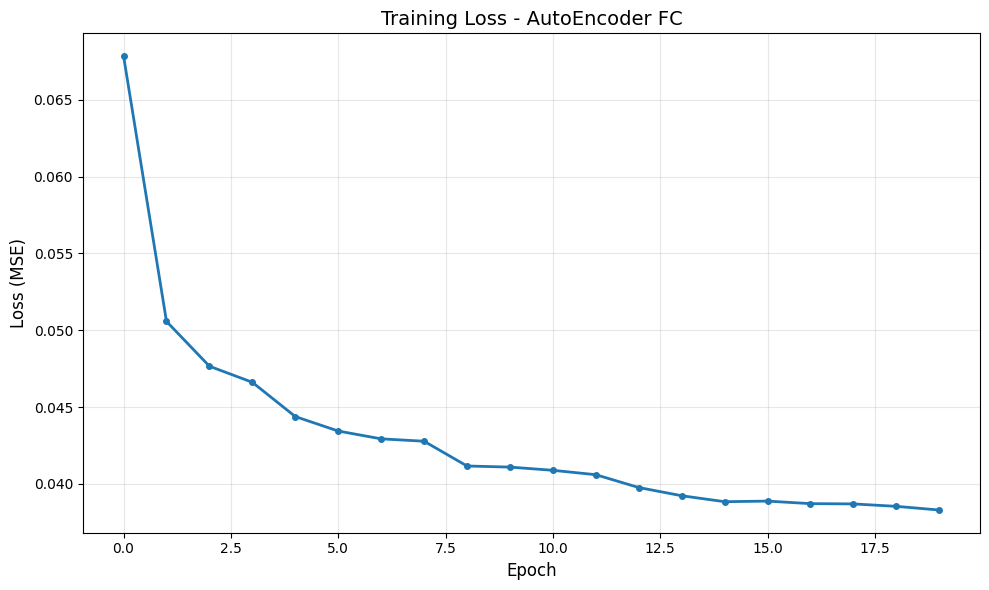

In [60]:
plt.figure(figsize=(10, 6))
file_path = 'images/plot_fc.png'
if(os.path.exists(file_path)):
    img = mpimg.imread(file_path)
    plt.imshow(img)
    plt.axis('off') 
else:
    plt.plot(fc_epochs_list, fc_train_loss, marker='o', linewidth=2, markersize=4)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Training Loss - AutoEncoder FC', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.savefig(file_path)

plt.tight_layout()
plt.show()


In [61]:
def valid_step_on_10(model, pair_loader, file_path_save, n_samples=5):
    model.eval()

    images = []    
    recreats = []
    
    with torch.no_grad():
        for i, (image, idx_class) in enumerate(pair_loader):
            if i >= n_samples:
                break
            
            image = image.to(device)
            outputs = model(image)
           
            img_np = image[0].cpu().numpy()
            out_np = outputs[0].cpu().numpy()
            
            if img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))
                out_np = np.transpose(out_np, (1, 2, 0))
                
            images.append(img_np)
            recreats.append(out_np)

    plt.figure(figsize=(12, 10))
    if(os.path.exists(file_path_save)):
        img = mpimg.imread(file_path_save)
        plt.imshow(img)
        plt.axis('off') 
    else:
        for i in range(len(images)):
            plt.subplot(len(images), 2, i * 2 + 1)
            plt.imshow(images[i])
            plt.axis('off')
            
            plt.subplot(len(images), 2, i * 2 + 2)
            plt.imshow(recreats[i])
            plt.axis('off')

        plt.savefig(file_path_save)
        
    plt.tight_layout()
    plt.show()

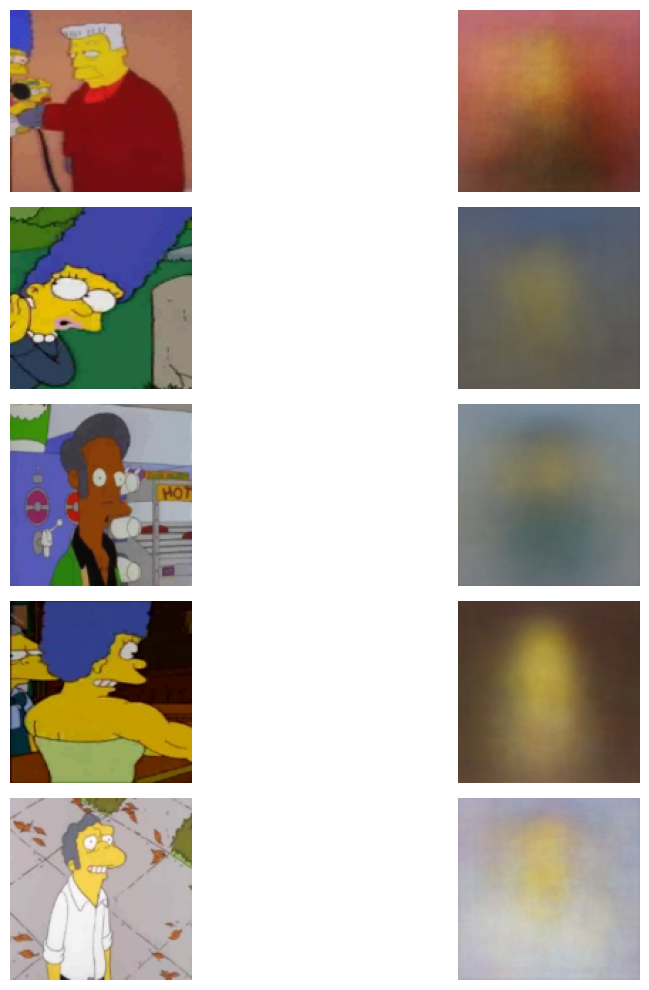

In [62]:
file_path_save_fc = 'images/diff_fc.png'
valid_step_on_10(model_fc, test_loader, file_path_save=file_path_save_fc)

In [63]:
inp_dim = 3
model_conv = AutoEncoder_Conv((3, 128, 128), inp_dim, 64).to(device)
criterion = nn.MSELoss()

conv_train_loss, conv_epochs_list, model_conv = train_system(train_loader, model_conv, criterion, device, lr=0.0015, resume_from='models/model2/', epochs=20)

Training on: cuda


/home/f.danilov/workflow/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/f.danilov/workflow/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1/20, Train Loss: 0.0759
Epoch: 2/20, Train Loss: 0.0429
Epoch: 3/20, Train Loss: 0.0360
Epoch: 4/20, Train Loss: 0.0333
Epoch: 5/20, Train Loss: 0.0318
Epoch: 6/20, Train Loss: 0.0230
Epoch: 7/20, Train Loss: 0.0193
Epoch: 8/20, Train Loss: 0.0175
Epoch: 9/20, Train Loss: 0.0161
Epoch: 10/20, Train Loss: 0.0154
Epoch: 11/20, Train Loss: 0.0142
Epoch: 12/20, Train Loss: 0.0130
Epoch: 13/20, Train Loss: 0.0125
Epoch: 14/20, Train Loss: 0.0118
Epoch: 15/20, Train Loss: 0.0114
Epoch: 16/20, Train Loss: 0.0117
Epoch: 17/20, Train Loss: 0.0106
Epoch: 18/20, Train Loss: 0.0103
Epoch: 19/20, Train Loss: 0.0100
Epoch: 20/20, Train Loss: 0.0097


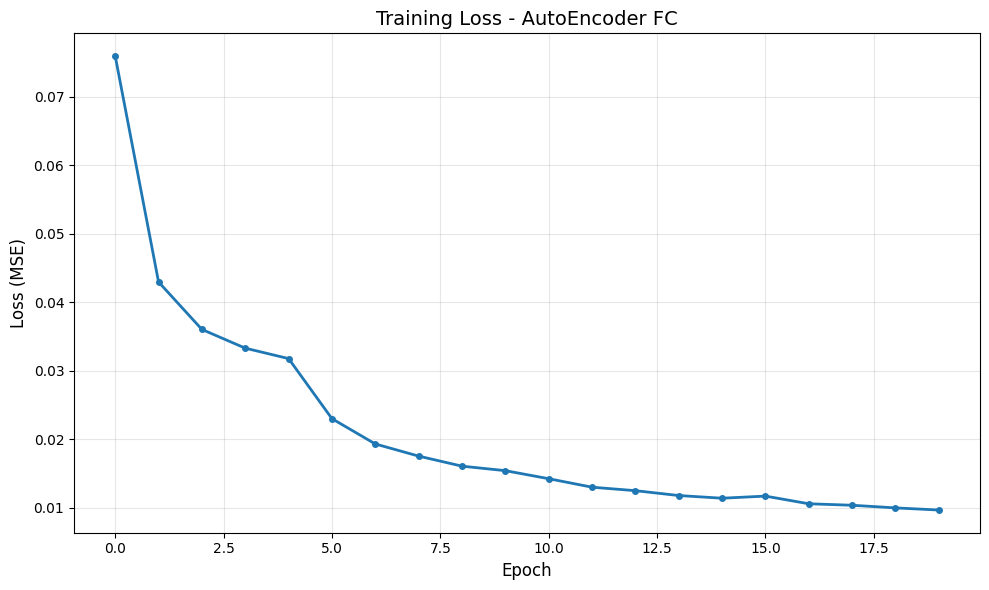

In [64]:
plt.figure(figsize=(10, 6))
file_path = 'images/plot_conv.png'
if(os.path.exists(file_path)):
    img = mpimg.imread(file_path)
    plt.imshow(img)
    plt.axis('off') 
else:
    plt.plot(conv_epochs_list, conv_train_loss, marker='o', linewidth=2, markersize=4)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Training Loss - AutoEncoder FC', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.savefig('images/plot_conv.png')

plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0241854].


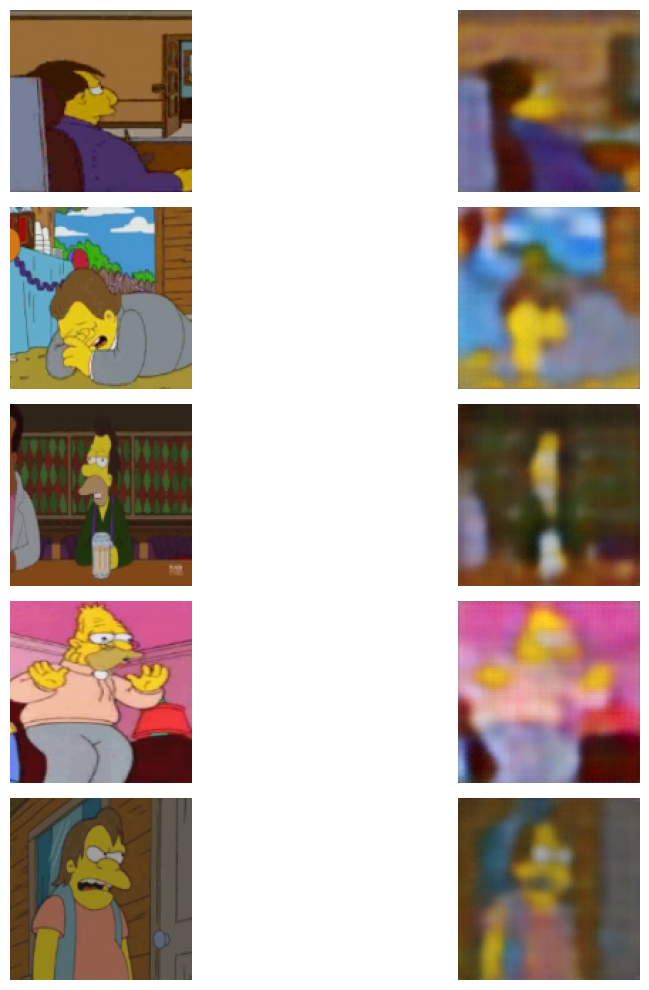

In [65]:
file_path_save_conv = 'images/diff_conv.png'
valid_step_on_10(model_conv, test_loader, file_path_save=file_path_save_conv)

### t-SNE

In [66]:
from sklearn.decomposition import PCA

def pca(model, loader, device='cuda'):
    recreats = []
    classes = []
    for image, idx_class in loader:
        image = image.to(device)
        outputs = model.encode(image)

        outputs = outputs.view(outputs.size(0), -1)
        
        recreats.append(outputs.detach().cpu().numpy())
        classes.append(idx_class.numpy())

    recreats = np.vstack(recreats)      
    classes = np.concatenate(classes)

    pca_compressor = PCA(n_components=2)
    data_compressed = pca_compressor.fit_transform(recreats)


    plt.figure(figsize=(10, 5))
    plt.scatter(data_compressed[:, 0], data_compressed[:, 1], c=classes)
    plt.title("Визуализация данных с PCA")
    plt.xlabel("Главная компонента 1")
    plt.ylabel("Главная компонента 2")
    plt.show()
    

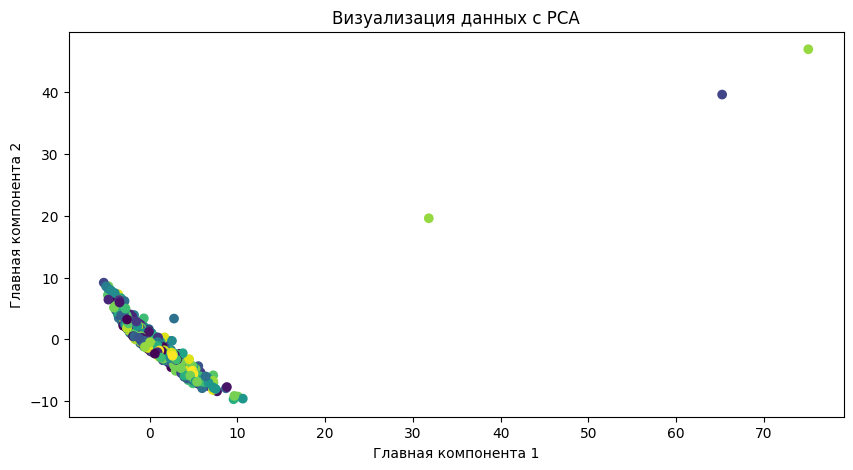

In [67]:
pca(model_conv, test_loader)            

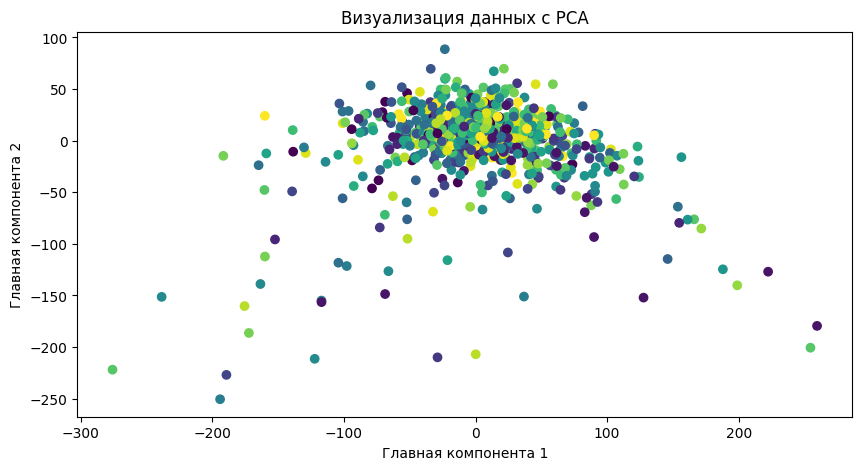

In [68]:
pca(model_fc, test_loader) 

In [69]:
def vizual_interactive(model, loader, device='cuda'):
    recreats = []
    latent_shape = None 
    for image, idx_class in loader:
        image = image.to(device)
        outputs = model.encode(image)

        if latent_shape is None:
                latent_shape = outputs.shape[1:]

        outputs = outputs.view(outputs.size(0), -1)

        recreats.append(outputs.detach().cpu().numpy())

    recreats = np.vstack(recreats)      

    pca_compressor = PCA(n_components=4)
    data_compressed = pca_compressor.fit_transform(recreats)
    return data_compressed, pca_compressor, latent_shape

In [70]:
compressed_conv, pca_compressor_conv, latent_shape = vizual_interactive(model_conv, train_loader)
compressed_conv.shape

(18742, 4)

In [71]:
pc_min_conv = compressed_conv.min(axis=0)
pc_max_conv = compressed_conv.max(axis=0)

print(pc_min_conv)
print(pc_max_conv)

[ -1.2657897 -29.332968   -9.103704  -10.92119  ]
[338.02155    17.635094   13.1844635  13.7951145]


In [72]:
from ipywidgets import interactive

def plot(z1, z2, z3, z4):
    plt.figure(2)
    z_pca = np.array([[z1, z2, z3, z4]])
    z_flat = pca_compressor_conv.inverse_transform(z_pca)
    z_tensor = torch.Tensor(z_flat).view(1, *latent_shape).to(device)
    
    with torch.no_grad():
            decoded = model_conv.decode(z_tensor)

    img = decoded.squeeze(0).cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

interactive_plot = interactive(plot, z1=(pc_min_conv[0], pc_max_conv[0], 0.01), z2=(pc_min_conv[1], pc_max_conv[1], 0.01), z3=(pc_min_conv[2], pc_max_conv[2], 0.01), z4=(pc_min_conv[3], pc_max_conv[3], 0.01))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=168.37420654296875, description='z1', max=338.02154541015625, min=-1.2…

In [73]:
compressed_fc, pca_compressor_fc, latent_shape_fc = vizual_interactive(model_fc, train_loader)
compressed_fc.shape

(18742, 4)

In [74]:
pc_min_fc = compressed_fc.min(axis=0)
pc_max_fc = compressed_fc.max(axis=0)

print(pc_min_fc)
print(pc_max_fc)

[-346.88293  -307.64484  -131.33463  -100.934006]
[250.07568 104.0077  141.85681 120.74141]


In [75]:
from ipywidgets import interactive

def plot(z1, z2, z3, z4):
    plt.figure(2)
    z_pca = np.array([[z1, z2, z3, z4]])
    z_flat = pca_compressor_fc.inverse_transform(z_pca)
    z_tensor = torch.Tensor(z_flat).view(1, *latent_shape_fc).to(device)
    
    with torch.no_grad():
            decoded = model_fc.decode(z_tensor)

    img = decoded.squeeze(0).cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

interactive_plot = interactive(plot, z1=(pc_min_fc[0], pc_max_fc[0], 0.01), z2=(pc_min_fc[1], pc_max_fc[1], 0.01), z3=(pc_min_fc[2], pc_max_fc[2], 0.01), z4=(pc_min_fc[3], pc_max_fc[3], 0.01))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=-48.412933349609375, description='z1', max=250.07568359375, min=-346.8…